[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/carlos-argueta/factor-graphs-from-scratch/blob/main/modules/01-nonlinear-least-squares/lesson.ipynb)

# Module 1 — Nonlinear least squares: the engine under everything

> **Goal.** Build the optimiser that every estimator in this course eventually calls into —
> **Gauss–Newton**, its damped and safe cousin **Levenberg–Marquardt**, and a **robust
> (Huber) kernel** — and ship it as `factorgraph/nls.py`. M0 showed that a Kalman `update()` is
> *one* Gauss–Newton step on *two* factors, started from the prior mean. This module removes
> both restrictions: **many** factors, **many** iterations, plus the two defences a real solve
> needs — *damping* so a bad initial guess can't blow the step up, and *robustness* so a few
> gross outliers can't hijack the fit.

The one line to carry forward from M0's line:

$$\boxed{\text{a batch smoother / SLAM solve} \;=\; \text{repeated Gauss–Newton on a stack of factors}}$$

From M3 on, every estimator we build does exactly one thing before calling this engine: it
**assembles the stack** $r(x)$, $J(x)$ from its factors. Everything else — how to descend it,
how to stay stable, how to survive outliers — is what we settle here, once.

In [1]:
import sys, pathlib, subprocess
import numpy as np

# --- Colab bootstrap -------------------------------------------------------
# On Google Colab the repository isn't present, so clone it once to make the
# course packages (`gaussian_filters`, `factorgraph`) importable.
# EDIT REPO_URL to point at your fork.
REPO_URL = "https://github.com/carlos-argueta/factor-graphs-from-scratch.git"
if "google.colab" in sys.modules:
    repo = pathlib.Path("/content/factor-graphs-from-scratch")
    if not repo.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(repo)], check=True)
    if str(repo / "src") not in sys.path:
        sys.path.insert(0, str(repo / "src"))

# --- Local: put the repo's src/ on the path (covers gaussian_filters + factorgraph)
def _add_src_to_path():
    here = pathlib.Path.cwd().resolve()
    for base in [here, *here.parents]:
        if (base / "src" / "gaussian_filters").exists():
            if str(base / "src") not in sys.path:
                sys.path.insert(0, str(base / "src"))
            return
_add_src_to_path()

np.set_printoptions(precision=5, suppress=True)

## 1 · From a Kalman update to a general least-squares engine

M0 built the whole MAP problem into a single **whitened residual stack**. Each source of
information — a prior, a measurement — was whitened (rescaled into σ-units) and its rows piled
into one vector $r(x)$, so that the negative-log-posterior became a plain sum of squares:

$$
C(x) \;=\; \tfrac12\,\lVert r(x)\rVert^2,
\qquad
r(x)=\begin{bmatrix} r_1(x)\\ r_2(x)\\ \vdots \\ r_N(x)\end{bmatrix},
\qquad
J(x)=\frac{\partial r}{\partial x}=\begin{bmatrix} J_1(x)\\ J_2(x)\\ \vdots \\ J_N(x)\end{bmatrix}.
$$

Every **factor** $i$ contributes a block of rows $r_i$ to $r$ and the matching block $J_i$ to
$J$. A Kalman `update()` was the smallest instance: $N=2$ blocks (prior + measurement) and a
**single** Gauss–Newton step taken from $x_0=\bar\mu$.

Nothing in that construction cares that $N=2$ or that we stop after one step:

- **Many factors.** A pose graph with a hundred poses and a thousand measurements just stacks
  a thousand more blocks. The *shape* of the problem is identical; only the stack is taller
  (and, from M3, **sparse** — each $J_i$ touches only the few variables its factor sees).
- **Many iterations.** When $h$ is nonlinear, one linearise-and-solve doesn't land on the
  minimum; we relinearise at the new estimate and repeat. The EKF's "one step from the prior
  mean" was a *deliberate simplification*, not a property of the maths.

So the job of this module is the two things left open once the stack exists:

1. **How do we minimise $C(x)$ when $h$ is nonlinear?** — Gauss–Newton (§2), and its damped,
   overshoot-proof version Levenberg–Marquardt (§4).
2. **How do we stop a handful of bad rows from dominating the sum of squares?** — robust
   (M-estimator) kernels, applied by reweighting (§5), which upgrade the objective to

   $$C(x)=\tfrac12\sum_i \rho\!\big(\lVert r_i(x)\rVert^2\big).$$

All three live in `factorgraph/nls.py`. We read the actual source as we go, then exercise it on a
concrete nonlinear fit.

## 2 · Gauss–Newton: the inner loop

### 2.1 · One step (recap from M0, stated for the general stack)

Gauss–Newton is the loop *linearise → solve → step*, repeated. Near the current estimate
$x_t$, replace the nonlinear residual by its first-order Taylor model,

$$
r(x_t+\delta)\;\approx\; r_t + J_t\,\delta,
\qquad r_t=r(x_t),\quad J_t=J(x_t),
$$

substitute into $C=\tfrac12\lVert r\rVert^2$, and minimise the resulting **exact quadratic** in
the step $\delta$. Its minimiser solves the **normal equations**

$$
\boxed{\;(J_t^\top J_t)\,\delta_t \;=\; -\,J_t^\top r_t\;}
\qquad\text{then}\qquad
x_{t+1}=x_t+\delta_t .
$$

M0 derived this in full — the quadratic expansion in **Appendix C**, and why the left-hand
matrix $J^\top J$ is the *Gauss–Newton approximation* to the true Hessian (it drops the
curvature term $\sum_i r_i\nabla^2 r_i$) in **Appendix B**. Two facts from that derivation drive
everything below:

- **The gradient is exact.** $\nabla C = J^\top r$ with no approximation, so the right-hand side
  $-J_t^\top r_t$ is the true steepest-descent direction (scaled). Only the *matrix* on the left
  is approximate.
- **$J^\top J$ is positive-semidefinite** by construction (it's a Gram matrix), so the step it
  produces always points downhill — provided the linear model is trusted, which is exactly the
  assumption LM will learn to police.

### 2.2 · The loop and when to stop

Written out, with iteration index $t$ from an initial guess $x_0$:

1. evaluate $r_t=r(x_t)$ and $J_t=J(x_t)$;
2. solve $(J_t^\top J_t)\,\delta_t=-J_t^\top r_t$;
3. update $x_{t+1}=x_t+\delta_t$;

and stop when the estimate stops moving. In `nls.py` we stop when **either** the step
$\lVert\delta_t\rVert$ **or** the relative cost change $|C_t-C_{t+1}|/C_t$ falls below a tolerance
— two views of the same "we've converged." (The gradient $\lVert J_t^\top r_t\rVert$ is a third,
scale-free option.)

### 2.3 · Why it usually converges fast — and when it doesn't

If $h$ were *linear*, $J$ would be constant, $C$ would be an exact paraboloid, and the very first
step would land on the minimum; a second step would return $\delta=0$. The iteration exists purely
to chase the **moving linearisation** of a *nonlinear* $h$.

Near the solution this chase is quick. The neglected curvature term $\sum_i r_i\nabla^2 r_i$ is
proportional to the residuals $r_i$, which shrink as the fit improves, so $J^\top J$ becomes an
ever-better Hessian and convergence is **superlinear** for a well-fitting (small-residual) model.
The failure mode is the mirror image: **far** from the solution, or on a **large-residual**
problem, the dropped curvature is *not* small, the quadratic model overpromises, and the raw GN
step can overshoot — sometimes catastrophically. That single weakness is the entire motivation for
Levenberg–Marquardt in §4. (The convergence rate is quantified in **Appendix C**.)

Let's read the real thing.

In [2]:
import inspect
from factorgraph import nls
print(inspect.getsource(nls.gauss_newton))

def gauss_newton(residual_fn: ResidualFn, x0, *, max_iters: int = 50,
                 tol: float = 1e-9, kernel: HuberKernel | None = None,
                 verbose: bool = False) -> NLSResult:
    """Minimise ``1/2||r(x)||^2`` by Gauss-Newton.

    Each step solves the normal equations ``(J^T J) dx = -J^T r`` (via a least
    squares solve for numerical stability) and applies ``x <- x + dx``. Stops
    when the step or the relative cost change falls below ``tol``.
    """
    x = np.array(x0, float).reshape(-1)
    r, J, cost = _eval(residual_fn, x, kernel)
    history = [cost]

    converged = False
    it = 0
    for it in range(1, max_iters + 1):
        # Solve J dx = -r in the least-squares sense (equivalent to the normal
        # equations but better conditioned than forming J^T J explicitly).
        dx, *_ = np.linalg.lstsq(J, -r, rcond=None)
        x_new = x + dx
        r, J, cost_new = _eval(residual_fn, x_new, kernel)

        if verbose:
            print(f"  GN it {it

Two implementation notes worth pausing on, because they recur in every solver in the file:

- **`np.linalg.lstsq(J, -r)` instead of forming $J^\top J$.** Solving $J\delta=-r$ in the
  least-squares sense gives the *same* $\delta$ as the normal equations but never explicitly
  builds $J^\top J$, whose condition number is the **square** of $J$'s. On a stiff problem that
  squaring is the difference between a usable and a useless solve — see **Appendix D**.
- **`_eval` folds the robust kernel in by row-scaling.** Every evaluation of $(r,J)$ can pass
  through a kernel that multiplies each row by a weight $w$ (§5). With no kernel, $w=1$ and it is
  plain least squares. This is why the *same* `gauss_newton` handles both the ordinary and the
  robust fit with no special-casing.

In [3]:
import matplotlib.pyplot as plt

# Shared palette + axis styling, reused by every figure in this lesson
# (same recessive-chrome look as Module 0).
BLUE, AQUA, VIOLET, RED = "#2a78d6", "#1baf7a", "#4a3aa7", "#e34948"
AMBER = "#d98a1f"
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

def _style(ax, title="", xlabel="", ylabel=""):
    if title:  ax.set_title(title, color=INK, fontsize=11, pad=8)
    if xlabel: ax.set_xlabel(xlabel, color=MUTED, fontsize=9)
    if ylabel: ax.set_ylabel(ylabel, color=MUTED, fontsize=9)
    ax.grid(True, color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(MUTED)
    ax.tick_params(colors=MUTED, labelsize=8)

print("palette + _style ready")

palette + _style ready


## 3 · A concrete fit: a noisy exponential

Fit $y = a\,e^{b t}$ to noisy samples — a genuinely **nonlinear** model in the parameters
$x=(a,b)$, so the linearisation actually has to be chased. The per-sample residual and its
Jacobian row come straight from differentiating $r_i = a e^{b t_i} - y_i$:

$$
r_i(x) = a\,e^{b t_i} - y_i,
\qquad
\frac{\partial r_i}{\partial a}=e^{b t_i},
\qquad
\frac{\partial r_i}{\partial b}=a\,t_i\,e^{b t_i},
$$

so the Jacobian row is $J_i=[\,e^{b t_i},\; a\,t_i e^{b t_i}\,]$. Stacking all $m$ samples gives
the $r\in\mathbb R^m$, $J\in\mathbb R^{m\times2}$ that the solver expects. (Note the residual is
*unwhitened* here — the sample noise is homoscedastic, so a common scale factor cancels out of the
normal equations and we can leave it off. With per-sample $\sigma_i$ you'd divide each row by its
$\sigma_i$, exactly as in M0.)

In [4]:
from factorgraph import gauss_newton, levenberg_marquardt, HuberKernel

rng = np.random.default_rng(0)
t = np.linspace(0, 2, 40)
a_true, b_true = 2.0, 0.9
y = a_true*np.exp(b_true*t) + 0.05*rng.standard_normal(t.size)

def residual(x):
    a, b = x
    e = np.exp(b*t)
    r = a*e - y
    J = np.stack([e, a*t*e], axis=1)
    return r, J

gn = gauss_newton(residual, [1.0, 0.5])
lm = levenberg_marquardt(residual, [1.0, 0.5])
print("truth        :", [a_true, b_true])
print("Gauss-Newton :", gn)
print("Levenberg-M  :", lm)

truth        : [2.0, 0.9]
Gauss-Newton : NLSResult(converged in 7 it, cost=0.0293281, x=[1.9899 0.9034])
Levenberg-M  : NLSResult(converged in 7 it, cost=0.0293281, x=[1.9899 0.9034])


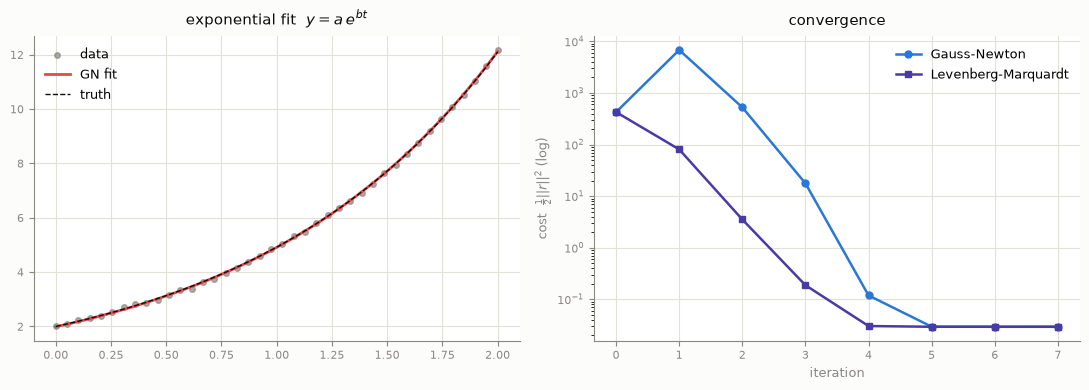

GN converged in 7 it; LM in 7 it. From a good start they agree to 5.3e-10.


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4), facecolor="#fcfcfb")

# left: data + fitted curve
tt = np.linspace(0, 2, 200)
ax[0].scatter(t, y, s=16, color=MUTED, alpha=0.7, label="data")
ax[0].plot(tt, gn.x[0]*np.exp(gn.x[1]*tt), color=RED, lw=2, label="GN fit")
ax[0].plot(tt, a_true*np.exp(b_true*tt), color=INK, lw=1, ls="--", label="truth")
_style(ax[0], r"exponential fit  $y=a\,e^{bt}$"); ax[0].legend(frameon=False, fontsize=9)

# right: cost per iteration (log)
ax[1].semilogy(gn.cost_history, "o-", color=BLUE,  lw=1.8, ms=5, label="Gauss-Newton")
ax[1].semilogy(lm.cost_history, "s-", color=VIOLET, lw=1.8, ms=4, label="Levenberg-Marquardt")
_style(ax[1], "convergence", xlabel="iteration", ylabel="cost  $\\frac{1}{2}||r||^2$ (log)")
ax[1].legend(frameon=False, fontsize=9)
fig.tight_layout(); plt.show()

print(f"GN converged in {gn.iterations} it; LM in {lm.iterations} it. "
      f"From a good start they agree to {np.max(np.abs(gn.x-lm.x)):.1e}.")

## 4 · Levenberg–Marquardt: damping the step

### 4.1 · Why Gauss–Newton overshoots

The GN step trusts the linear model $r\approx r_t+J_t\delta$ **completely** and jumps to that
model's exact minimum. Near the solution the model is accurate and the jump is superb. Far from
it, the model is only a local tangent — extrapolated across a big $\delta$ it can be wildly wrong,
so the "minimum" it points at may sit **higher** than where we started. GN takes the jump anyway.
On a stiff problem that overshoot compounds into divergence (you'll see a raw GN step throw a
linear-algebra error further below).

### 4.2 · The damped normal equations

The fix is to distrust the model in proportion to how far it's asking us to move. Add a
non-negative **damping** term $\lambda$ to the normal-equations matrix:

$$
\boxed{\;\big(J^\top J + \lambda\,D\big)\,\delta \;=\; -\,J^\top r\;}
$$

The right-hand side (the exact gradient) is untouched; only the matrix changes, and the two
extremes are the whole story:

- $\lambda\to 0$: recover $(J^\top J)\delta=-J^\top r$ — the **Gauss–Newton** step. *Trust the
  model.*
- $\lambda\to\infty$: the $\lambda D$ term dominates, so $\delta\approx -\tfrac1\lambda D^{-1}J^\top r$
  — a **tiny step along (a rescaling of) the gradient**, i.e. gradient descent with step
  $\sim 1/\lambda$. *Trust nothing; inch downhill.*

So $\lambda$ interpolates continuously between the fast-but-reckless Newton-like step and the
slow-but-safe gradient step. Because $J^\top J$ is positive-semidefinite and $\lambda D$ is
positive-definite, $J^\top J+\lambda D$ is **positive-definite** for any $\lambda>0$ — always
invertible, always a descent direction, even where raw GN's $J^\top J$ is singular.

**Levenberg vs Marquardt — what is $D$?** Levenberg's original choice was $D=I$ (add $\lambda$ to
the diagonal). Marquardt's refinement, and what `nls.py` uses, is $D=\mathrm{diag}(J^\top J)$:
damp **each parameter in proportion to its own curvature**. This makes the step invariant to
rescaling the parameters (measuring $b$ in different units shouldn't change the trajectory) and
damps stiff and slack directions on their own terms rather than uniformly. The trust-region reading
that makes this precise — $\lambda$ as the Lagrange multiplier of a step-size constraint — is
**Appendix A**.

### 4.3 · The adaptation loop

$\lambda$ is not a fixed knob; it's steered by whether the last step actually helped:

- Solve for $\delta$, evaluate the cost at $x+\delta$.
- **If the cost went down**, the model was trustworthy here: **accept** the step and *relax* the
  damping ($\lambda \leftarrow \lambda/\text{down}$), edging back toward fast Gauss–Newton.
- **If it didn't**, the model overpromised: **reject** the step and *raise* the damping
  ($\lambda \leftarrow \lambda\cdot\text{up}$), shortening and straightening the next attempt
  toward gradient descent. Retry from the same point.

This is a crude **trust region**: $\lambda$ large ⇔ trust region small. It is exactly what GTSAM's
`LevenbergMarquardtOptimizer` does (with a more elaborate acceptance test), and it's why LM
tolerates an initial guess that would send Gauss–Newton off a cliff. Read the source:

In [6]:
print(inspect.getsource(nls.levenberg_marquardt))

def levenberg_marquardt(residual_fn: ResidualFn, x0, *, max_iters: int = 100,
                        tol: float = 1e-9, lambda0: float = 1e-3,
                        lambda_up: float = 10.0, lambda_down: float = 10.0,
                        kernel: HuberKernel | None = None,
                        verbose: bool = False) -> NLSResult:
    """Minimise ``1/2||r(x)||^2`` by Levenberg-Marquardt (damped Gauss-Newton).

    Solves ``(H + lambda * diag(H)) dx = -g`` with ``H = J^T J`` and ``g = J^T r``.
    A step that lowers the cost is accepted and the damping is *relaxed*
    (trust region grows, -> Gauss-Newton); a step that doesn't is rejected and the
    damping is *raised* (-> gradient descent). Far more robust to a bad ``x0`` than GN.
    """
    x = np.array(x0, float).reshape(-1)
    r, J, cost = _eval(residual_fn, x, kernel)
    history = [cost]
    lam = lambda0

    converged = False
    it = 0
    for it in range(1, max_iters + 1):
        H = J.T @ J
        g = J.T @ r
    

### 4.4 · A hostile initial guess

Start the fit from far away, $x_0=(10,-2)$ — the wrong sign on the growth rate and a wildly
wrong amplitude. Watch the **cost per iteration**: this is the honest picture, not "GN explodes,
LM is fine" but something sharper.

In [7]:
x0_bad = [10.0, -2.0]
gn_bad = gauss_newton(residual, x0_bad, max_iters=100)
lm_bad = levenberg_marquardt(residual, x0_bad, max_iters=200)

print("from a bad start", x0_bad)
print(f"  GN: converged={gn_bad.converged}  final cost={gn_bad.cost:.4g}  x={gn_bad.x}")
print(f"  LM: converged={lm_bad.converged}  final cost={lm_bad.cost:.4g}  x={lm_bad.x}")
print()
print("first few costs")
print("  GN:", [f"{c:.2g}" for c in gn_bad.cost_history[:7]])
print("  LM:", [f"{c:.2g}" for c in lm_bad.cost_history[:7]])

from a bad start [10.0, -2.0]
  GN: converged=True  final cost=0.02933  x=[1.98988 0.90338]
  LM: converged=True  final cost=0.02933  x=[1.98988 0.90338]

first few costs
  GN: ['7.5e+02', '1.6e+05', '1.1e+04', '1.1e+03', '37', '5', '0.031']
  LM: ['7.5e+02', '5.3e+02', '76', '38', '0.034', '0.029', '0.029']


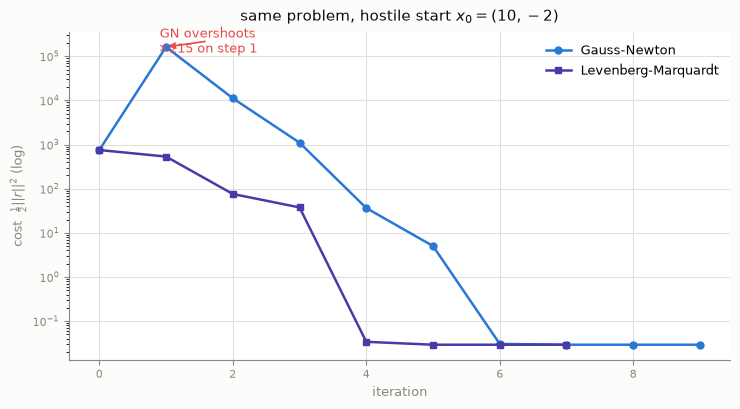

Both eventually reach the same minimum here — but note the paths:
 • GN's linear model, extrapolated from far away, OVERSHOOTS: its cost leaps
   ~200x on the first step before it claws back down (non-monotone, risky).
 • LM throttles itself with damping and descends monotonically, every step downhill.
 • On a stiffer problem that GN overshoot doesn't recover — it diverges:
   raw GN from x0=(1e-3, 8.0) blows up -> LinAlgError: SVD did not converge in Linear Least Squares
   ...while LM from the same point is fine: True


/tmp/ipykernel_13944/539406074.py:10: RuntimeWarning: overflow encountered in exp
  e = np.exp(b*t)


In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.2), facecolor="#fcfcfb")
ax.semilogy(gn_bad.cost_history, "o-", color=BLUE,  lw=1.8, ms=5, label="Gauss-Newton")
ax.semilogy(lm_bad.cost_history, "s-", color=VIOLET, lw=1.8, ms=4, label="Levenberg-Marquardt")

# mark GN's first-step overshoot
c0, c1 = gn_bad.cost_history[0], gn_bad.cost_history[1]
ax.annotate(f"GN overshoots\n×{c1/c0:.0f} on step 1",
            (1, c1), color=RED, fontsize=9, ha="center",
            textcoords="offset points", xytext=(30, -4),
            arrowprops=dict(arrowstyle="->", color=RED, lw=1.2))
_style(ax, "same problem, hostile start $x_0=(10,-2)$",
       xlabel="iteration", ylabel="cost  $\\frac{1}{2}||r||^2$ (log)")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); plt.show()

print("Both eventually reach the same minimum here — but note the paths:")
print(" • GN's linear model, extrapolated from far away, OVERSHOOTS: its cost leaps")
print("   ~200x on the first step before it claws back down (non-monotone, risky).")
print(" • LM throttles itself with damping and descends monotonically, every step downhill.")
print(" • On a stiffer problem that GN overshoot doesn't recover — it diverges:")

# demonstrate the divergence risk without crashing the notebook
try:
    gauss_newton(residual, [1e-3, 8.0], max_iters=50)
    print("   (no error this run)")
except Exception as exc:
    print(f"   raw GN from x0=(1e-3, 8.0) blows up -> {type(exc).__name__}: {exc}")
print("   ...while LM from the same point is fine:",
      levenberg_marquardt(residual, [1e-3, 8.0], max_iters=400).converged)

## 5 · Robust kernels: a few outliers shouldn't win

### 5.1 · The problem with plain squares

Least squares grows the cost **quadratically** with each residual: a row that is $10\sigma$ off
contributes $100$ to the sum, a $100\sigma$ blunder contributes $10{,}000$. So one gross outlier —
a GPS multipath fix, a mismatched loop closure, a wheel slip — can outweigh *hundreds* of good
measurements and drag the entire estimate toward itself. The optimiser is doing its job perfectly;
the objective is simply wrong about how much a wild residual should matter.

### 5.2 · M-estimators: bend the cost

The fix is to replace each squared term by a function $\rho$ that grows **sub-quadratically** for
large residuals — an **M-estimator**. Writing $e=\lVert r_i\rVert$ for a residual's whitened
magnitude, the objective becomes

$$
C(x)=\sum_i \rho(e_i),
\qquad
\rho(e)=\tfrac12 e^2 \ \text{for small } e,
\quad
\rho(e)\ \text{grows slower than } e^2\ \text{for large } e.
$$

Two derived functions describe its behaviour:

- the **influence function** $\psi(e)=\rho'(e)$ — how hard a residual of size $e$ pulls on the
  solution. For plain squares $\psi(e)=e$, *unbounded*: bigger error, bigger pull, forever. A
  robust $\rho$ **caps** $\psi$, so beyond some point a larger error pulls no harder.
- the **weight** $w(e)^2=\psi(e)/e$ — the factor by which we down-weight that row (motivated in
  §5.4).

### 5.3 · The Huber kernel

Huber is the gentlest robust choice: **keep least squares where it's working, cap the pull where
it isn't.** Quadratic inside a band $|e|\le\delta$, linear outside:

$$
\rho_\delta(e)=
\begin{cases}
\tfrac12 e^2, & |e|\le\delta,\\[4pt]
\delta\big(|e|-\tfrac12\delta\big), & |e|>\delta,
\end{cases}
\qquad
\psi_\delta(e)=
\begin{cases}
e, & |e|\le\delta,\\
\delta\,\operatorname{sign}(e), & |e|>\delta,
\end{cases}
\qquad
w_\delta(e)^2=\frac{\psi_\delta(e)}{e}=
\begin{cases}
1, & |e|\le\delta,\\[4pt]
\dfrac{\delta}{|e|}, & |e|>\delta.
\end{cases}
$$

Inside the band nothing changes ($w=1$, ordinary least squares). Outside, the influence flattens
to the constant $\delta$ — an outlier keeps a *fixed*, bounded pull no matter how gross — and the
row's weight decays like $1/|e|$. The band $\delta$ is the dial: everything within a few σ is
"good data, trust it fully"; everything beyond is "suspicious, cap it."

### 5.4 · Applying it by reweighting (IRLS), and "square-rooting the kernel"

We have a solver that minimises a plain sum of squares $\tfrac12\lVert r\rVert^2$; we want it to
minimise the *robust* cost $C(x)=\sum_i\rho(e_i)$ instead — **without rewriting the solver**. The
plan is to show that at any point the robust cost has the **same gradient** as an ordinary
*weighted* least-squares cost. Since a solver only ever looks at gradients (and the GN Hessian
model), matching the gradient is enough: our least-squares engine can minimise the robust cost if we
feed it the right weights. So set $\nabla C=0$ and see what falls out, one step at a time.

**Step 1 — differentiate the robust cost.** With $e_i=\lVert r_i\rVert$ the residual's magnitude, the
chain rule on each term $\rho(e_i)$ gives

$$
\nabla C=\nabla\sum_i\rho(e_i)=\sum_i \rho'(e_i)\,\nabla e_i=\sum_i \psi(e_i)\,\nabla e_i ,
$$

using $\psi=\rho'$, the influence function from §5.2. (Plain least squares is $\rho(e)=\tfrac12e^2$,
so $\psi(e)=e$ and this collapses back to $\sum_i e_i\nabla e_i$ — the familiar case.)

**Step 2 — differentiate the magnitude.** The magnitude depends on $x$ only through $r_i$, and

$$
\nabla e_i=\nabla\lVert r_i\rVert=\frac{r_i}{\lVert r_i\rVert}\,\nabla r_i=\frac{r_i}{e_i}\,\nabla r_i
$$

(for a scalar residual this is simply $\nabla|r_i|=\operatorname{sign}(r_i)\,\nabla r_i$). Substitute
that into Step 1 and group the two scalar factors:

$$
\nabla C=\sum_i \psi(e_i)\,\frac{r_i}{e_i}\,\nabla r_i
        =\sum_i \underbrace{\frac{\psi(e_i)}{e_i}}_{\textstyle w_i^2}\; r_i\,\nabla r_i .
$$

**Step 3 — recognise a weighted least-squares gradient.** Now write the gradient of an *ordinary*
weighted least-squares cost $C_w(x)=\tfrac12\sum_i w_i^2\,r_i^2$ with the weights $w_i$ **held
constant**:

$$
\nabla C_w=\sum_i w_i^2\,r_i\,\nabla r_i .
$$

This is **term-for-term identical** to $\nabla C$ once $w_i^2=\psi(e_i)/e_i$. So the robust cost and a
weighted sum of squares share the *same* stationarity condition — minimising one minimises the other
— *provided each weight carries the value* $\psi(e_i)/e_i$. This is where the weight
$w^2=\psi/e$ promised back in §5.2 actually comes from.

**Step 4 — the weights move, so iterate (IRLS).** The catch: $w_i^2=\psi(e_i)/e_i$ depends on the
residual $e_i$, which changes every time $x$ moves — so it is not a fixed weighted problem we can
solve once. Instead we **freeze the weights at their current values, solve that weighted
least-squares problem, recompute the weights from the new residuals, and repeat** — *iteratively
reweighted least squares (IRLS)*. Each inner solve is exactly what our GN/LM engine already does;
robustness is just a weight refreshed between iterations.

**Step 5 — apply the weight by row-scaling ("square-rooting the kernel", after Triggs).** IRLS still
needs each weighted solve carried out by a solver that only knows *plain* sums of squares. `factorgraph`
does this without ever forming a weight matrix: it **scales residual row $i$ and Jacobian row $i$ by
the single number $w_i=\sqrt{w_i^2}$** and hands the scaled $\tilde r,\tilde J$ to the *unmodified*
normal equations. A "row" here is one residual — entry $i$ of the stacked vector $r$ — together with
its Jacobian row $J_i$ (that residual's derivatives w.r.t. all parameters). Two things to see.

*Why the square root.* Look at the weighted **cost** we are trying to hit — the $C_w$ *defined* in
Step 3 (the line above its gradient):

$$
C_w(x)=\tfrac12\sum_i w_i^2\,r_i^2 ,
$$

where the weight $w_i^2$ multiplies the **squared** residual $r_i^2$. But our solver takes *residuals*
and squares them *itself* ($C=\tfrac12\lVert r\rVert^2=\tfrac12\sum_i(\text{row}_i)^2$). So to make the
solver land on the term $w_i^2 r_i^2$, we must hand it a row whose *square* is $w_i^2 r_i^2$ — namely
the *un-squared* residual $\sqrt{w_i^2}\,r_i=w_i r_i$, since $(w_i r_i)^2=w_i^2 r_i^2$. The weight lives
on the squared term in the cost, so its **square root** goes on the residual row — that is all
"square-rooting the kernel" means. (The first-power $r_i$ you see in Step 3's *gradient*
$\sum_i w_i^2 r_i\nabla r_i$ is that same cost differentiated; the object being matched to the solver
here is the cost, not the gradient.)

*Why both rows, and why plain GN/LM then suffices.* GN/LM build the cost, the gradient, and the
normal-equations matrix **entirely** from $\tilde r$ and $\tilde J$. Scale row $i$ of *both* by $w_i$
and all three come out correctly weighted, with the solver none the wiser:

| solver forms | from the scaled rows | equals |
|---|---|---|
| cost $\tfrac12\lVert\tilde r\rVert^2$ | $\tfrac12\sum_i(w_i r_i)^2$ | $\tfrac12\sum_i w_i^2 r_i^2$ |
| gradient $\tilde J^\top\tilde r$ | $\sum_i(w_i J_i)^\top(w_i r_i)$ | $\sum_i w_i^2\,J_i^\top r_i$ — Step 3's gradient |
| GN matrix $\tilde J^\top\tilde J$ | $\sum_i(w_i J_i)^\top(w_i J_i)$ | $\sum_i w_i^2\,J_i^\top J_i$ |

Scaling $r$ *alone* would leave the gradient with one power of $w$ instead of $w^2$; the Jacobian row
must be scaled by the **same** $w_i$ so the two factors multiply to the $w_i^2$ Step 3 demands. With
both scaled, $(\tilde J^\top\tilde J)\,\delta=-\tilde J^\top\tilde r$ *is* the weighted least-squares
system — so plain, unmodified GN/LM solves the robust problem. In `nls.py` this is the three lines of
`_eval`: `w = kernel.weights(r); r = w*r; J = w[:, None]*J`.

For Huber the weight is $w=1$ inside the band (ordinary least squares, untouched) and
$w=\sqrt{\delta/|r|}<1$ for a row with $|r|>\delta$ — shrinking **both** that outlier's residual and
its Jacobian row so it pulls less on the solve. Read the kernel — it is precisely those weights: (the
fuller M-estimator picture, and Cauchy/Tukey alternatives, is **Appendix B**.)

In [9]:
print(inspect.getsource(nls.HuberKernel))

@dataclass
class HuberKernel:
    """Huber M-estimator, applied per scalar residual via IRLS weights.

    Quadratic for small residuals (``|r| <= delta``) and linear beyond, so a
    gross outlier contributes ~linearly instead of quadratically. We realise it
    by scaling each residual and its Jacobian row by ``w = sqrt(weight)`` so the
    ordinary normal equations on the scaled system implement the reweighting
    (Triggs' "square-rooting the kernel").
    """

    delta: float = 1.0

    def weights(self, r: np.ndarray) -> np.ndarray:
        """Per-residual IRLS weight ``w`` such that the scaled row is ``w * r``."""
        a = np.abs(np.asarray(r, float))
        # weight on the squared cost is 1 inside the band, delta/|r| outside;
        # the residual/Jacobian get sqrt of that.
        w = np.ones_like(a)
        out = a > self.delta
        w[out] = np.sqrt(self.delta / a[out])
        return w



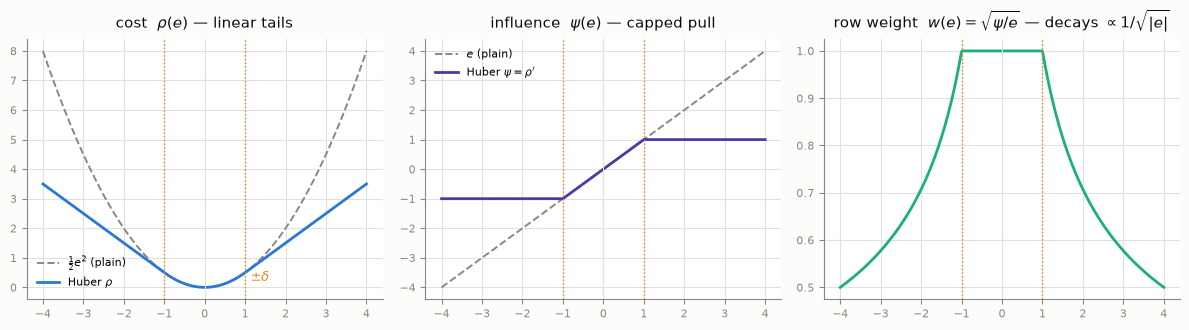

Inside |e|<=delta Huber IS least squares (w=1); outside, influence flattens to +/-delta.


In [10]:
# The three faces of the Huber kernel: cost rho, influence psi, weight w.
delta = 1.0
e = np.linspace(-4, 4, 400)
ae = np.abs(e)
rho  = np.where(ae <= delta, 0.5*e**2, delta*(ae - 0.5*delta))
psi  = np.where(ae <= delta, e, delta*np.sign(e))
w    = np.where(ae <= delta, 1.0, np.sqrt(delta/np.maximum(ae, 1e-12)))

fig, ax = plt.subplots(1, 3, figsize=(12, 3.4), facecolor="#fcfcfb")
ax[0].plot(e, 0.5*e**2, color=MUTED, lw=1.4, ls="--", label="$\\frac{1}{2}e^2$ (plain)")
ax[0].plot(e, rho, color=BLUE, lw=2, label="Huber $\\rho$")
_style(ax[0], r"cost  $\rho(e)$ — linear tails"); ax[0].legend(frameon=False, fontsize=8)
ax[1].plot(e, e, color=MUTED, lw=1.4, ls="--", label="$e$ (plain)")
ax[1].plot(e, psi, color=VIOLET, lw=2, label="Huber $\\psi=\\rho'$")
_style(ax[1], r"influence  $\psi(e)$ — capped pull"); ax[1].legend(frameon=False, fontsize=8)
ax[2].plot(e, w, color=AQUA, lw=2)
_style(ax[2], r"row weight  $w(e)=\sqrt{\psi/e}$ — decays $\propto 1/\sqrt{|e|}$")
for a in ax:
    for s in (-delta, delta):
        a.axvline(s, color=AMBER, ls=":", lw=1)
    a.axvline(0, color=GRID, lw=0.8)
ax[0].annotate("$\\pm\\delta$", (delta, 0.2), color=AMBER, fontsize=9,
               textcoords="offset points", xytext=(4, 0))
fig.tight_layout(); plt.show()
print("Inside |e|<=delta Huber IS least squares (w=1); outside, influence flattens to +/-delta.")

### 5.5 · Outliers on the exponential fit

Corrupt two of the forty samples with gross blunders and refit — plain LM versus LM with a Huber
kernel of band $\delta=0.5$.

truth : [2.0, 0.9]
plain : [3.02285 0.59624]   <- dragged by the two outliers
robust: [1.99049 0.90263]   <- Huber recovers the fit


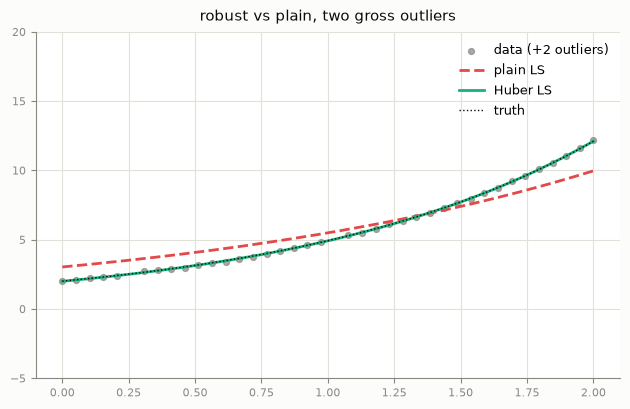

OK: the robust fit is closer to truth than the plain fit.


In [11]:
y_out = y.copy()
y_out[5] = 50.0; y_out[20] = -30.0            # two gross outliers

def residual_out(x):
    a, b = x
    e = np.exp(b*t)
    return a*e - y_out, np.stack([e, a*t*e], axis=1)

plain  = levenberg_marquardt(residual_out, [1.0, 0.5])
robust = levenberg_marquardt(residual_out, [1.0, 0.5], kernel=HuberKernel(delta=0.5))
print("truth :", [a_true, b_true])
print("plain :", plain.x, "  <- dragged by the two outliers")
print("robust:", robust.x, "  <- Huber recovers the fit")

fig, ax = plt.subplots(figsize=(6.4, 4.2), facecolor="#fcfcfb")
ax.scatter(t, y_out, s=18, color=MUTED, alpha=0.7, label="data (+2 outliers)")
ax.plot(tt, plain.x[0]*np.exp(plain.x[1]*tt),  color=RED,  lw=2, ls="--", label="plain LS")
ax.plot(tt, robust.x[0]*np.exp(robust.x[1]*tt), color=AQUA, lw=2, label="Huber LS")
ax.plot(tt, a_true*np.exp(b_true*tt), color=INK, lw=1, ls=":", label="truth")
ax.set_ylim(-5, 20)
_style(ax, "robust vs plain, two gross outliers"); ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); plt.show()

assert np.linalg.norm(robust.x - [a_true, b_true]) < 0.2, "Huber should recover truth"
assert (np.linalg.norm(plain.x - [a_true, b_true])
        > np.linalg.norm(robust.x - [a_true, b_true])), "robust must beat plain"
print("OK: the robust fit is closer to truth than the plain fit.")

## 6 · Tie-back and takeaways

1. **Gauss–Newton is the inner loop of every estimator in this course.** Build $J$ and $r$ from
   the factors, solve $(J^\top J)\delta=-J^\top r$, step, repeat. M0's Kalman update was a *single*
   such step from the prior mean; a batch smoother is *many* steps over *many* factors — same loop,
   taller stack.
2. **Levenberg–Marquardt adds damping so a bad initial guess can't blow the step up.** $\lambda$
   slides the step from reckless Gauss–Newton ($\lambda\to0$) to safe gradient descent
   ($\lambda\to\infty$), steered by whether each step actually lowered the cost. This is GTSAM's
   default optimiser, and the reason it survives a first GPS fix or a fresh loop closure.
3. **Robust kernels stop a few outliers from hijacking the fit** by reweighting each residual row
   (IRLS) — realised as a $\sqrt{\cdot}$ row-scale so the plain solver does the work unchanged.
   Huber caps each outlier's influence at a constant instead of letting it grow quadratically.

**Where this leads.** These three ideas are what make graph-based estimation work on real robots:

- the **outlier rejection** here is what field robots (boats, drones, legged platforms) need to
  survive multipath GPS and foot-slip — in **M8** we reuse Huber not as a fit trick but as a
  **factor noise model**;
- **LM's damping** is the principled replacement for the ad-hoc update-gating heuristics that filter
  implementations often bolt on by hand;
- and the whole "**one GN step = a filter; many = a smoother**" picture is the bridge we cross in
  **M7**, recasting a filter as a fixed-lag smoother and benchmarking the two on the same
  ATE/RPE/NEES metrics.

**What's still missing.** We wrote one monolithic `residual(x)` returning a *dense* $J$. Real
problems have **many small factors**, each touching **a few variables**, so $J$ is **sparse** and
the graph structure is what makes the solve tractable. Building that — variables, factors, the
bipartite graph, the sparse linear solve — is **Module 3** (with the Gaussian/information-form
theory it rests on in **Module 2**).

➡️ See `exercises.ipynb`.

## Appendix

### A · Levenberg–Marquardt as a trust-region method

§4 introduced $\lambda$ as a damping knob interpolating between Gauss–Newton and gradient descent.
Here is the sharper reading: **$\lambda$ is the Lagrange multiplier of a step-size constraint**, and
that is what makes LM a genuine *trust-region* method.

**The constrained subproblem.** Instead of minimising the linearised model $\tfrac12\lVert r+J\delta\rVert^2$
over *all* $\delta$ (which is raw Gauss–Newton, and may extrapolate the model absurdly far), minimise
it only within a region where we still *trust* the model — a ball of radius $\Delta$:

$$
\min_{\delta}\ \tfrac12\lVert r+J\delta\rVert^2
\qquad\text{subject to}\qquad \lVert D^{1/2}\delta\rVert \le \Delta .
$$

The weighting $D^{1/2}$ makes the "ball" an ellipsoid shaped by the parameters' own scales.

**The multiplier.** Forming the Lagrangian $\tfrac12\lVert r+J\delta\rVert^2 + \tfrac{\lambda}{2}
(\lVert D^{1/2}\delta\rVert^2-\Delta^2)$ and setting its $\delta$-gradient to zero gives

$$
J^\top(r+J\delta) + \lambda D\,\delta = 0
\quad\Longleftrightarrow\quad
(J^\top J + \lambda D)\,\delta = -J^\top r,
$$

**exactly the damped normal equations of §4.2.** So each value of $\lambda$ corresponds to solving
the GN model inside a trust region of some radius $\Delta(\lambda)$: large $\lambda$ ⇔ small
$\Delta$ (short, cautious step), $\lambda\to0$ ⇔ $\Delta\to\infty$ (the unconstrained GN step). The
accept/grow/shrink loop of §4.3 is a **trust-region manager** — it never sets $\Delta$ directly, but
by raising or lowering $\lambda$ it grows the region after a successful step and shrinks it after a
failed one.

**Why $D=\mathrm{diag}(J^\top J)$ (Marquardt) beats $D=I$ (Levenberg).** With $D=I$ the trust region
is a sphere in *parameter* space, so its meaning changes if you rescale a parameter (switch $b$ from
per-second to per-minute) — the same physical step counts as "large" or "small" purely by unit
choice, and stiff directions get over-damped while slack ones get under-damped. Taking
$D=\mathrm{diag}(J^\top J)$ scales each axis by that parameter's own curvature $\partial^2 C/\partial x_j^2$,
making the ellipsoidal trust region **invariant to diagonal rescaling** of the parameters and damping
each direction on its own terms. This is why it converges more reliably on badly-scaled problems —
the common case once a graph mixes translations (metres) and rotations (radians).

**Note on the acceptance test.** `nls.py` accepts any step that lowers the true cost and rejects any
that doesn't — the simplest possible rule. Production LM (GTSAM, Ceres, MINPACK) compares the
*actual* cost reduction to the reduction the quadratic model *predicted* — the **gain ratio**
$\varrho = \frac{C(x)-C(x+\delta)}{\text{model decrease}}$ — and scales $\lambda$ by a factor
depending on $\varrho$ (e.g. Nielsen's rule). It is a refinement of the same accept-and-relax /
reject-and-tighten logic, worth knowing when you read GTSAM's optimiser but not needed to understand
what it does.

### B · From a robust kernel $\rho$ to IRLS weights

§5.4 asserted that minimising $\sum_i\rho(e_i)$ is a sequence of weighted least-squares solves with
weight $w_i^2=\psi(e_i)/e_i$. Here is the derivation in full, plus where Huber sits among the common
kernels.

**The stationarity condition.** With $e_i=\lVert r_i(x)\rVert$ and objective $C(x)=\sum_i\rho(e_i)$,
differentiate. Using $\partial e_i/\partial x = (r_i/e_i)^\top\partial r_i/\partial x$ (the chain rule
through the norm) and $\rho'(e)=\psi(e)$,

$$
\nabla C=\sum_i \psi(e_i)\,\frac{1}{e_i}\,J_i^\top r_i
        =\sum_i \Big(\underbrace{\tfrac{\psi(e_i)}{e_i}}_{w_i^2}\Big)\,J_i^\top r_i
        = J^\top W\,r,
\qquad W=\operatorname{diag}(w_i^2).
$$

Setting $\nabla C=0$ is identical to the normal-equations gradient of the **weighted** least-squares
cost $\tfrac12\sum_i w_i^2 e_i^2 = \tfrac12\lVert W^{1/2}r\rVert^2$ **with the weights held fixed**.
That fixed-weight problem is ordinary least squares. So:

> **IRLS.** Repeat: (1) from the current $x$, compute residuals $e_i$ and weights
> $w_i^2=\psi(e_i)/e_i$; (2) solve the plain weighted LS problem with those weights; (3) update $x$.

The weights lag the residuals by one iteration, which is why IRLS is itself iterative — and why it
folds so cleanly into the GN/LM loop, which is *already* iterating and relinearising. In `factorgraph` the
weight is applied as a **row scale** $w_i$ (its square root), so the unmodified solver sees a plain
$\tfrac12\lVert \tilde r\rVert^2$ with $\tilde r_i = w_i r_i$ — the "square-rooting the kernel" trick.

**Why the weight has the form $\psi(e)/e$.** It is precisely the factor that turns the robust
influence $\psi(e)$ back into the linear influence $e$ of least squares: $w^2 e = \psi(e)$. A row with
a capped influence is treated *as if* it were a smaller, well-behaved residual — down-weighted just
enough that a plain solver reproduces the robust pull.

**The common kernels** (as functions of $e$, with $\psi=\rho'$ and $w^2=\psi/e$):

| kernel | $\rho(e)$ (large $e$) | influence $\psi(e)$ | weight $w^2(e)$ | outliers |
|---|---|---|---|---|
| **L2** (plain) | $e^2/2$ | $e$ (unbounded) | $1$ | dominate |
| **Huber** | $\delta(\lvert e\rvert-\delta/2)$ linear | capped at $\pm\delta$ | $\min(1,\delta/\lvert e\rvert)$ | bounded pull |
| **Cauchy** | $\tfrac{c^2}{2}\log(1+(e/c)^2)$ | $\to 0$ | $1/(1+(e/c)^2)$ | fade out |
| **Tukey** | constant (redescending) | $0$ beyond $c$ | $0$ beyond $c$ | fully rejected |

The trade-off runs top to bottom: **Huber** never fully discards a point (its influence stays at the
constant $\delta$), so it is safe and convex — no risk of throwing away good data, but a *very* gross
outlier still exerts a small steady pull. **Cauchy** and **Tukey** *redescend* — their influence
falls back toward zero, so extreme outliers are effectively deleted — but they are non-convex and can
get stuck in local minima if the initial guess is poor. The standard recipe is to start with Huber
(convex, forgiving) and, if needed, switch to a redescending kernel once the estimate is close. M8's
SLAM loop closures are the first place we'll actually reach for these.

### C · Convergence of Gauss–Newton: rate, and the residual that governs it

§2.3 claimed GN converges superlinearly on small-residual problems and can crawl or diverge on
large-residual ones. The rate follows directly from M0 **Appendix B**'s split of the true Hessian.

**The two Hessians.** The exact Hessian of $C=\tfrac12\lVert r\rVert^2$ is

$$
\nabla^2 C \;=\; \underbrace{J^\top J}_{\text{what GN uses}} \;+\; \underbrace{S(x)}_{\text{what GN drops}},
\qquad S(x)=\sum_i r_i\,\nabla^2 r_i .
$$

GN is Newton's method with $\nabla^2 C$ replaced by $J^\top J$, i.e. with the curvature term $S$ set
to zero. Standard fixed-point analysis of that substitution gives the asymptotic error contraction

$$
\lVert x_{t+1}-x^\star\rVert \;\le\; \underbrace{\big\lVert (J^\top J)^{-1} S(x^\star)\big\rVert}_{\;=\,\kappa\;}\;\lVert x_t-x^\star\rVert \;+\; O\big(\lVert x_t-x^\star\rVert^2\big).
$$

Everything hinges on the constant $\kappa=\lVert (J^\top J)^{-1}S(x^\star)\rVert$ — the size of the
neglected curvature *relative to* the kept curvature, at the solution:

- **Zero-residual problem** ($r(x^\star)=0$, a model that fits perfectly): $S(x^\star)=0$, so $\kappa=0$
  and the linear term vanishes — only the $O(\lVert\cdot\rVert^2)$ survives. Convergence is
  **quadratic**, as fast as full Newton, at none of the cost of second derivatives. This is the
  regime a well-tuned estimator lives in: residuals are a few σ, $S$ is tiny, GN screams.
- **Small-residual problem**: $\kappa$ is small but nonzero, convergence is **linear with a tiny
  rate** — practically superlinear. Still excellent.
- **Large-residual or strongly-curved problem**: $\kappa$ can approach or exceed $1$. Near $\kappa=1$
  convergence stalls; for $\kappa>1$ the map is *expanding* and GN **diverges** — the overshoot §4.1
  and §4.4 showed in the wild. This is precisely where damping earns its keep: LM's $\lambda D$ term
  shrinks the step until progress resumes, trading GN's speed for guaranteed descent.

**Tie-back to the filter.** The EKF is one GN step from $x_0=\bar\mu$, so it inherits this exactly:
its update is statistically clean only when $h$ is near-linear over the prior's spread (small $S$) —
the same condition under which a single GN step is nearly a full Newton step. When it isn't, the EKF
is biased for the identical reason GN struggles, and the graph-world fix is the identical one:
iterate (relinearise) and damp.

### D · Why the code solves $J\delta=-r$ by `lstsq`, not by inverting $J^\top J$

§2 wrote the step as $\delta=-(J^\top J)^{-1}J^\top r$, but `gauss_newton` never forms $J^\top J$ — it
calls `np.linalg.lstsq(J, -r)`. The reason is **conditioning**, and it is worth internalising because
the same choice governs how GTSAM and Ceres factor their systems.

**The condition number squares.** The sensitivity of a linear solve to rounding error is measured by
the condition number $\kappa(\cdot)$. For the two ways of getting $\delta$:

$$
\kappa(J^\top J) \;=\; \kappa(J)^2 .
$$

Forming the normal-equations matrix **squares** the conditioning. If $J$ has $\kappa(J)=10^6$ (routine
once a problem mixes stiff and slack directions — think metres against radians, or a nearly-degenerate
geometry), then $\kappa(J^\top J)=10^{12}$, and in IEEE double precision (~16 significant digits) you
have thrown away twelve of them *before the solve even starts*. Half your precision, gone, purely from
the choice to multiply $J^\top$ by $J$.

**What `lstsq` does instead.** It solves the least-squares problem $\min_\delta\lVert J\delta+r\rVert$
via an orthogonal factorisation (SVD, or QR), which operates on $J$ **directly** and so pays only
$\kappa(J)$, never $\kappa(J)^2$. Same answer in exact arithmetic; far more surviving digits in real
arithmetic.

**The cost, and why production solvers still form the matrix.** The price of the orthogonal route is
speed and sparsity: it is dearer per solve, and it does not exploit the fact that a factor-graph $J$ is
mostly zeros. So large-scale libraries *do* work with $J^\top J$ (or the information matrix $\Lambda$)
— but they factor it with a **sparse Cholesky** decomposition on a carefully **reordered** variable
elimination (the Bayes-tree machinery of M5), which recovers both the speed and, with pivoting/ordering
care, acceptable conditioning. `factorgraph`'s dense `lstsq` is the *readable, always-stable* default for the
small problems of these early modules; the sparse, matrix-forming path is a deliberate later optimisation
once we understand the graph structure that makes it safe. Both compute the very same Gauss–Newton step.